##### <font color=red> Here, we have 2 datasets that have been produced using Polypen: 1) Marco2 and 2) Anna3_Barley_Polypen_16May (ROSA NEW). Unlike other datasets (Anna1, Anna2, Marco1, Michele, Original datset), they do not contain all wavelengths X397-X1003. Moreover, the wavelengths increase in it 1-by-1 and as such, they are many. </font>
##### Task Description
- Old task (done only on Marco2): Fe Deficiency detection based on the different hyperspectral spectral imaging (i.e., measuring leaf reflectance at different wavelengths in the range of 400 to 1000 nm). In this task, once we consider 1) all Wavelengths [397-792] and find the matches in the "Original Dataset" which leads to 117 Features, 2) Trimmed version of the dataset [449-792] and find the matches in the "Original Dataset" which leads to 135 Features. <font color=red>The SHAP plots are for class 1 which is "Fe deficiency" here. </font>

- New Task: Validate the indexes created in Phase1 & Phase2 of "Hyperspectral_FeDeficiency_BiClassification_IndexCreation.ipynb" by measuring the accuracy, using <font color=red> ONLY THE EXISTENT features </font> of those phases in our merged test set "Merged_Anna3_Marco2".

##### More details about Anna3 and Marco2 datasets:
- Anna3_Barley_Polypen_16May (ROSA NEW): Out of 253 samples, 130 are –Fe+N, 62 are +Fe-N, and 61 are +Fe+N 
- Marco2: Out of 77 samples, 24 are +N–Fe and 53 are +N+Fe +N+Fe-P
- We ignore "+N", "-N", "-P" and map them all into 2 categories 1) -Fe and 2) Fe ---> Finally, we have 154 -Fe and 176 +Fe samples in "Merged_Anna3_Marco2"
  
##### Methods
- Logistic Regression (Linear)
- Random Forest

In [1]:
# Essential Libraries
import pandas as pd
import shap
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, make_scorer,  precision_score,  recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.decomposition import PCA
from sklearn.utils import shuffle
# Initialize JavaScript for SHAP visualizations
shap.initjs()


#### Load and Preprocess
- Drop the 'Leaf' column as it provides no classification information (it has the same value 'YL' for all rows)
- Encode the 'Thesis' column (the ground-truth label)
- Separate the dataset into features and labels
- check class imbalance in the whole dataset
- Check for missing values in the entire DataFrame (There was none)
- Feature selection - Get feature importances using Random Forest
- Scale the feature values (Columns here) using Z-Score method

##### <font color=red> Important Notes </font>
- For executing the "Trimmed" version, uncomment all reduced variables (X_reduced, feature_names_reduced, X_scaled after reducing dimensions). Comment them if you wish to consider "All Wavelengths"
- Watch the consistency between encoded labels of the all datasets to be consistent
- Execute the Train&Test sets that are in the same Phases


Thesis
0    108
1     72
Name: count, dtype: int64


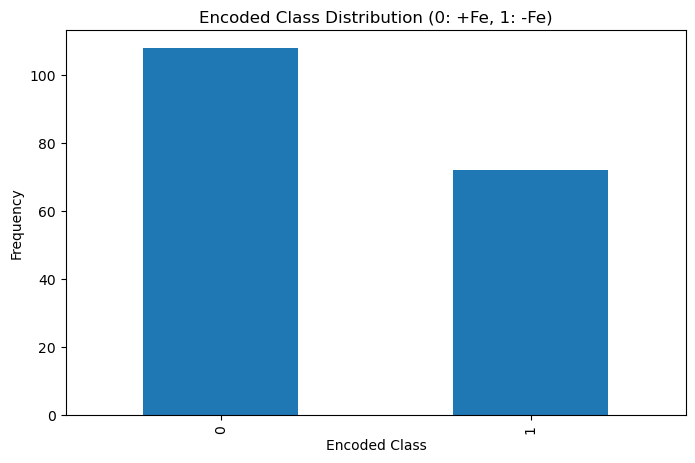

feature_names: 3
['X702.58', 'X699.60', 'X525.10']
Class Distribution:
Thesis
+N+Fe    72
+N-Fe    72
-N+Fe    36
Name: count, dtype: int64


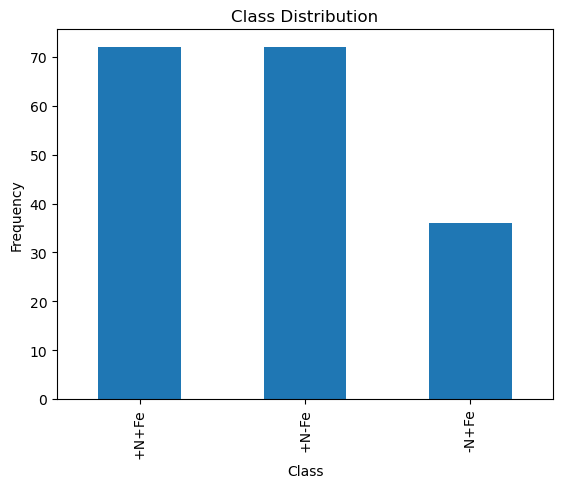

Columns with missing values: []

Number of features with 0.0 importance: 0


(180, 3)

In [41]:
# Step 1: Load the Train dataset
# *********** Phase 1's train set ************
# Load the "original dataset"
# data = pd.read_csv('Dati_HIS_Serra_Cs_Hv_Sl_Zm_no_Fe.txt', delimiter='\t')
# *********** Phase 2's train set ************
# Load the "original dataset + 36_Randomly_chosen_Michele_samples"
data = pd.read_csv('Dati_HIS_Serra_Cs_Hv_Sl_Zm_no_Fe_add36_randomly.txt', delimiter='\t')
# Step 2: Preprocess the data
# Drop the 'leaf' column
data = data.drop(columns=['Leaf'])
# If you want "All Wavelengths in Marco2, except for the last feature that does not exist in the Original dataset" ---> [397-792] or 135 features
# X = data.iloc[:, 3:138]
# If you want "trimmed Wavelengths in Marco2, except for the last feature that does not exist in the Original dataset" ---> [449-792] or 117 features
# X = data.iloc[:, 21:138]

###################### OLD ANALYSIS ######################
# select only important Wavelengths introduced by SHAP, Remove "reduced-related" codes for these states
# For Marco2 Dataset, All Features, Logistic Regression
# desired_columns = ['X714.55', 'X717.54','X711.56', 'X720.54', 'X723.53', 'X708.57', 'X726.53', 'X705.57', 'X729.53']
# For Marco2 Dataset, Some Features, Logistic Regression
# desired_columns = ['X714.55', 'X717.54', 'X711.56', 'X708.57', 'X720.54', 'X705.57', 'X702.58', 'X726.53', 'X699.60']
# For Marco2 Dataset, All Features, Random Forest
# desired_columns = ['X714.55', 'X708.57', 'X711.56', 'X717.54', 'X705.57', 'X699.60', 'X560.30', 'X702.58', 'X720.54']
# For Marco2 Dataset, Some Features, Random Forest
# desired_columns = ['X714.55', 'X705.57', 'X711.56', 'X708.57', 'X702.58', 'X699.60', 'X720.54', 'X551.49', 'X545.62']
# Trimmed Version
# select only important Wavelengths introduced by SHAP, Remove "reduced-related" codes for these states
# For Marco2 Dataset, All Features, LogisticRegression
# desired_columns = ['X714.55', 'X717.54', 'X720.54', 'X711.56', 'X723.53', 'X708.57', 'X726.53', 'X705.57', 'X729.53']
# For Marco2 Dataset, Some Features, Logistic Regression
# desired_columns = ['X717.54', 'X714.55', 'X723.53', 'X711.56', 'X708.57', 'X726.53', 'X705.57', 'X702.58', 'X747.54']
# For Marco2 Dataset, All Features, Random Forest
# desired_columns = ['X708.57', 'X705.57', 'X714.55', 'X717.54', 'X548.55', 'X702.58', 'X699.60', 'X711.56', 'X533.89']
# For Marco2 Dataset, Some Features, Random Forest
# desired_columns = ['X705.57', 'X711.56', 'X560.30', 'X536.82', 'X717.54', 'X702.58', 'X554.43', 'X533.89', 'X513.40']
###################### OLD ANALYSIS ######################


#### Only Use the FEATURES that the SHAP method detected as important WHEN All TRIMMED WAVELENGTHS WERE CONSIDERED ####
## select only important Wavelengths introduced by SHAP, comment "reduced-related" codes, and also "X = data.iloc[]" above  for these states
    ### Phase 1's wavelenghs ###
# For Merged Dataset, All Features, LogisticRegression, deleted 'X819.95'
# desired_columns = ['X714.55', 'X717.54', 'X711.56', 'X720.54', 'X708.57', 'X723.53', 'X726.53', 'X729.53']
# For Merged Dataset, All Features, Random Forest
# desired_columns = ['X702.58', 'X714.55', 'X705.57', 'X708.57', 'X711.56', 'X717.54', 'X563.24', 'X542.68', 'X720.54']
    ### Phase 2's wavelenghs ### --> using a new train set that has been augmented with 36 RANDOMLY-added features ###
# LogisticRegression, deleted 'X929.68'
# desired_columns =['X723.53','X720.54','X726.53','X501.72','X504.64', 'X507.56', 'X498.80', 'X449.35']
# Random Forest
# desired_columns = ['X702.58', 'X699.60', 'X714.55', 'X705.57', 'X525.10', 'X708.57','X696.61', 'X711.56','X569.12']

#### New Ablation Test ----> Use Phase 2's SHAP wavelenghs/features ###
# LogisticRegression, Use Top 4 SHAP features
# desired_columns=['X723.53', 'X720.54', 'X726.53', 'X501.72']
# RandomForest, Use Top 4 SHAP features
# desired_columns=['X702.58', 'X699.60', 'X714.55', 'X705.57']
# LogisticRegression, Use Top unique SHAP features, deleted 'X929.68'
# desired_columns=['X723.53', 'X501.72', 'X498.80'] 
# RandomForest, Use Top unique SHAP features
desired_columns=['X702.58', 'X699.60', 'X525.10']


X = data[desired_columns]
y = data['Thesis']
# if you execute "original dataset" as train/ Phase1, then comment the encoding lines below
# Encode the 'Thesis' column
# le = LabelEncoder()
# y = le.fit_transform(y)
# Encode 'Thesis' column based on "+Fe" and "-Fe"
y = data['Thesis'].apply(lambda label: 0 if '+Fe' in label else 1)
# Confirm the encoding
print(y.value_counts())  # Displays the distribution of 0s and 1s
plt.figure(figsize=(8, 5))
y.value_counts().plot(kind='bar')
plt.title('Encoded Class Distribution (0: +Fe, 1: -Fe)')
plt.xlabel('Encoded Class')
plt.ylabel('Frequency')
plt.show()
# Extract feature names and numeric parts for matching
feature_names = X.columns.tolist()
feature_numbers = [name[1:].split(".")[0] for name in feature_names if name.startswith("X")]
print("feature_names:",len(feature_names))
print(feature_names)

# Check the distribution/imbalance of the target variable
class_distribution = data['Thesis'].value_counts()
# Print the class distribution
print("Class Distribution:")
print(class_distribution)
# Visualize the class distribution
class_distribution.plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.show()

# Encode the 'Thesis' column
le = LabelEncoder()
y = le.fit_transform(y)

# Check for missing values --> none
print(f"Columns with missing values: {data.columns[data.isnull().any()].tolist()}")

# Feature selection ------------------>??
rf = RandomForestClassifier(n_estimators=15, random_state=42)
rf.fit(X, y)
feature_importances = pd.Series(rf.feature_importances_, index=X.columns)
# Count the number of features with 0.0 importance and print their names
zero_importance_features = feature_importances[feature_importances == 0.0].index.tolist()
print(f"\nNumber of features with 0.0 importance: {len(zero_importance_features)}")
# print("Features with 0.0 importance:", zero_importance_features)
# print("\nFeature Importances:")
# print(feature_importances.sort_values(ascending=False))

# Remove zero importance features from X
# X_reduced = X.drop(columns=zero_importance_features)
# feature_names_reduced = X_reduced.columns.tolist()
# print("\nX_reduced.shape is ", X_reduced.shape)
# print("\nX_reduced names.shape is ", len(feature_names_reduced))
# print(feature_names_reduced)
#Scale the feature/columns values
scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X_reduced)
X_scaled = scaler.fit_transform(X)
X_scaled.shape

### Test Set Preparation
#### Marco2

In [80]:
# # Load the .xlsx file into a pandas DataFrame
# df = pd.read_excel('Marco_lupin_Polypen_last_day_24_0_2025.xlsx')

# # Drop rows that are entirely empty
# df = df.dropna(how='all')

# # Save the DataFrame to a .txt file (tab-separated or space-separated)
# df.to_csv('Marco2.txt', sep='\t', index=False)


#### Merge Anna3_Barley_Polypen_16May & Marco2

In [3]:
# # Load Marco2
# df_Marco2 = pd.read_csv('Marco2.txt', delimiter='\t')
# # Load Anna3_Barley
# df_anna3 = pd.read_csv('Anna3_Barley_Polypen_16May.txt', delimiter='\t')
# # Drop columns 10 to 20 (Python uses zero-based indexing, so column indices range from 9 to 19)
# df_anna3 = df_anna3.drop(df_anna3.columns[3:56], axis=1)
# # Rename the "treatment" column to "Name" in df_anna3
# df_anna3.rename(columns={'treatment': 'Name', 'index': 'Index'}, inplace=True)

# # Verify the column name change
# print(df_anna3.columns)

# # Verify the resulting DataFrame
# print(df_anna3.head())
# print(df_Marco2.head())

# # Compare column names before merging
# diff_columns = set(df_anna3.columns) ^ set(df_Marco2.columns)
# print("Columns causing the issue:", diff_columns)


# # Verify the shape of the final data
# print("df_anna3.shape =",df_anna3.shape)
# print("df_Marco2.shape =",df_Marco2.shape)
# Anna3_Marco2 = pd.concat([df_anna3, df_Marco2])
# print("Final shape:", Anna3_Marco2.shape)  # Should print (86, 207)

# # Ensure df_Marco2 has the same columns as df_anna3 before merging
# df_Marco2.columns = df_anna3.columns  
# # Merge while keeping headers
# Anna3_Marco2 = pd.concat([df_anna3, df_Marco2], ignore_index=True)
# # Save with headers
# Anna3_Marco2.to_csv('Merged_Anna3_Marco2.txt', sep='\t', index=False, header=True)

# # ##  Save the combined data to a new tab-delimited .txt file
# # Anna3_Marco2.to_csv('Merged_Anna3_Marco2.txt', sep='\t', index=False, header=False)

Index(['Time', 'Index', 'Name', '380', '381', '382', '383', '384', '385',
       '386',
       ...
       '784', '785', '786', '787', '788', '789', '790', '791', '792', '793'],
      dtype='object', length=417)
                  Time  Index     Name       380       381       382  \
0  16/05/2025 08:12:18      1   -Fe +N  0.171378  0.166938  0.171085   
1  16/05/2025 08:12:39      2   -Fe +N  0.210511  0.216331  0.219966   
2  16/05/2025 08:12:49      3   -Fe +N  0.222390  0.226009  0.229026   
3  16/05/2025 08:13:13      4   -Fe +N  0.161483  0.164053  0.161543   
4  16/05/2025 08:13:25      5   -Fe +N  0.149690  0.148793  0.149511   

        383       384       385       386  ...       784       785       786  \
0  0.177062  0.176206  0.175250  0.173456  ...  0.445579  0.445003  0.445255   
1  0.223340  0.224056  0.224524  0.221148  ...  0.462143  0.461601  0.461668   
2  0.232059  0.235093  0.237852  0.234947  ...  0.489803  0.488999  0.488822   
3  0.157948  0.156832  0.155937  0.1

test_feature_names are: 414
Index(['Time', 'Index', 'Name', '380', '381', '382', '383', '384', '385',
       '386',
       ...
       '784', '785', '786', '787', '788', '789', '790', '791', '792', '793'],
      dtype='object', length=417)
Matched features: ['525', '699', '702']
Shape of y_te (labels from second file): (330,)
    X702.58   X699.60   X525.10
0  0.340921  0.403450  0.414980
1  0.397786  0.439901  0.447180
2  0.420836  0.465560  0.473157
3  0.360386  0.411357  0.431971
4  0.328086  0.391880  0.415103
Class Distribution:
 Thesis
0    176
1    154
Name: count, dtype: int64


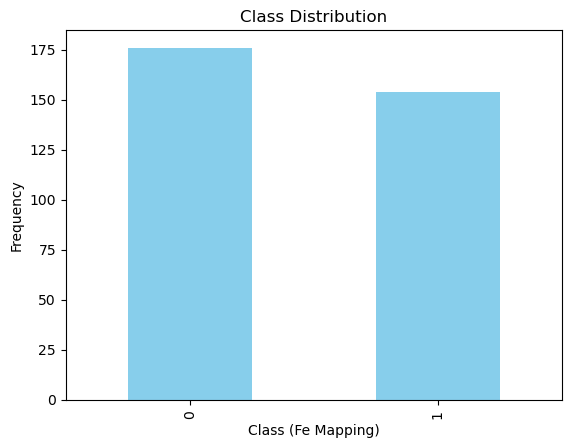

Columns with missing values: []
Encoded labels (y_te): [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Columns with missing values: []
(330, 3)


In [42]:
# Step 2: Load and process the second dataset
# Load Marco2
# test_df = pd.read_csv('Marco2.txt', delimiter='\t')
# Load Merged file of Anna3&Marco2
test_df = pd.read_csv('Merged_Anna3_Marco2.txt', delimiter='\t')
test_feature_names = test_df.columns[3:]  #397-792 must be filtered
print("test_feature_names are:",len(test_feature_names))
# Rename the "treatment" column to "Name" in df_Marco2
df_Marco2.rename(columns={'treatment': 'Name'}, inplace=True)

# Verify the column name change
print(df_Marco2.columns)

# Step 3: Match feature names between the two datasets
# Match features by comparing numeric parts (ignoring the "X" prefix)
# Match and filter columns
matched_features = [col for col in test_feature_names if col in feature_numbers]
X_te = test_df[matched_features]
X_te.columns = [feature_names[feature_numbers.index(col)] for col in matched_features]
print("Matched features:", matched_features)

# Step 5: Continue with the rest of the second file's processing
# Rename the column "Name" to "Thesis" for consistency
test_df.rename(columns={'Name': 'Thesis'}, inplace=True)

# Map target labels for the second dataset
y_te = test_df['Thesis'].apply(lambda x: 0 if '+Fe' in x else 1 if '-Fe' in x else None)
print("Shape of y_te (labels from second file):", y_te.shape)

 
# Map the labels (+Fe to 0, -Fe to 1)
# test_df['Fe_Mapping'] = test_df['Thesis'].apply(
#     lambda x: 0 if '+Fe' in x else 1 if '-Fe' in x else None
# )

X_te.columns = X.columns  # Update the column names to match those in X
print(X_te.head())

# Check class distribution
class_distribution = y_te.value_counts()
print("Class Distribution:\n", class_distribution)

# Visualize class distribution
class_distribution.plot(kind='bar', color='skyblue')
plt.title('Class Distribution')
plt.xlabel('Class (Fe Mapping)')
plt.ylabel('Frequency')
plt.show()

# Validate data quality (check for missing values)
missing_columns = test_df.columns[test_df.isnull().any()].tolist()
print(f"Columns with missing values: {missing_columns}")

# Encode the 'Thesis' column if needed
le_te = LabelEncoder()
y_te_encoded = le_te.fit_transform(y_te)
print("Encoded labels (y_te):", y_te_encoded)



# Check for missing values --> none
print(f"Columns with missing values: {test_df.columns[test_df.isnull().any()].tolist()}")

# # Remove zero importance features from X_te
# X_reduced_te = X_te.drop(columns=zero_importance_features)
# feature_names_reduced = X_reduced_te.columns.tolist()
# print("\nX_reduced_te.shape is ", X_reduced_te.shape)
# print("\nX_reduced_te names.shape is ", len(feature_names_reduced))
# # Scale the feature/columns values
scaler = StandardScaler()
# X_scaled_te = scaler.fit_transform(X_reduced_te)
X_scaled_te = scaler.fit_transform(X_te)
print(X_scaled_te.shape)


#### Very important: Check if encoded labels are consistant in original and each of the tested datasets

In [43]:
print("Label Encoding Mapping:")
for i, label in enumerate(le.classes_):
    print(f"{label}: {i}")

# print("Label Encoding Mapping:")
# for i, label in enumerate(le_te.classes_):
#     print(f"{label}: {i}")


# Systematic check for encoding using y_te
print("Label Encoding Mapping:")
for label in test_df['Thesis'].unique():
    encoded_value = y_te[test_df['Thesis'] == label].iloc[0]  # Find the corresponding encoded value from y_te
    print(f"{label}: {encoded_value}")


# # Display the original and encoded values in the Thesis column
# print("Original and Encoded Thesis Labels:")
# test_df_miki['Original_Thesis'] = pd.read_csv('Exp_4_Specie_Michele_Fe_and_N.txt', delimiter='\t')['Thesis']  # Reload original data for comparison
# print(test_df_miki[['Original_Thesis', 'Thesis']].drop_duplicates())



Label Encoding Mapping:
0: 0
1: 1
Label Encoding Mapping:
 -Fe +N: 1
 +Fe +N: 0
 +Fe -N: 0
 +N-Fe: 1
 +N+Fe: 0
 +N+Fe-P: 0


#### <font color=red> New </font>
#### - Train Set: all of the data data in the "original" dataset
#### - Test Set: all of the data data in "Anna1, Anna2, Marco" dataset


In [44]:
# 😎😎😎😎😎😎 new line
X_train, y_train = X_scaled, y
X_test, y_test = X_scaled_te, y_te

# Confirm the shape of the train and test sets
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (180, 3), y_train shape: (180,)
X_test shape: (330, 3), y_test shape: (330,)


#### Hyperparameter Tuning Using GridSearchCV , Model Training, and Evaluation
- Linear Logistic Regression </font>
- Randomforest

- <font color=red> Crossfold Validation in GridSearch (Hyperparameter tuning)</font>

#### <font color=green> Standard Logistic Regression </font>

Best parameters for Logistic Regression: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}

Cross-Validation Scores from GridSearchCV:
     mean_test_score  std_test_score  \
0          0.800000        0.107439   
1          0.805556        0.055556   
2          0.794444        0.098758   
3          0.800000        0.064310   
4          0.805556        0.055556   
5          0.800000        0.064310   
6          0.794444        0.067128   
7          0.794444        0.067128   
8          0.794444        0.067128   
9          0.794444        0.113312   
10         0.794444        0.113312   
11         0.794444        0.113312   
12         0.800000        0.107439   
13         0.800000        0.107439   
14         0.800000        0.107439   

                                               params  
0     {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}  
1   {'C': 0.01, 'penalty': 'l2', 'solver': 'liblin...  
2       {'C': 0.01, 'penalty': 'l2', 'solver': 'sag'}  
3      {'C': 

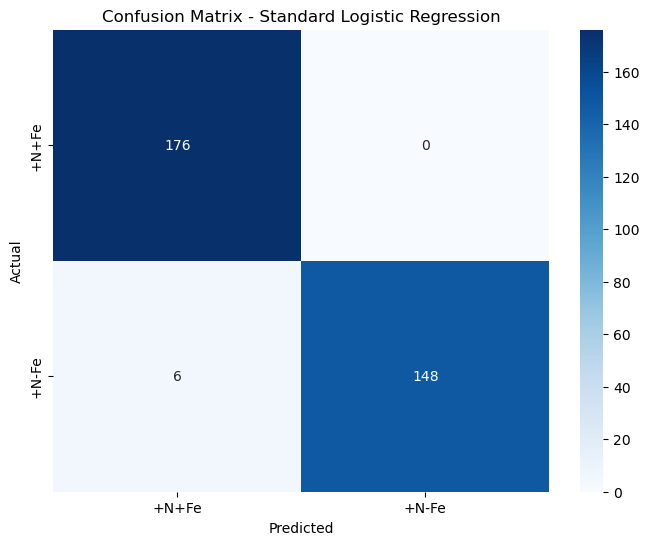

Linear Logistic Regression shap_values shape is (330, 3)


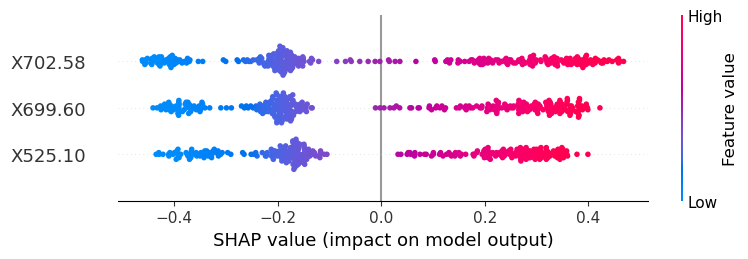

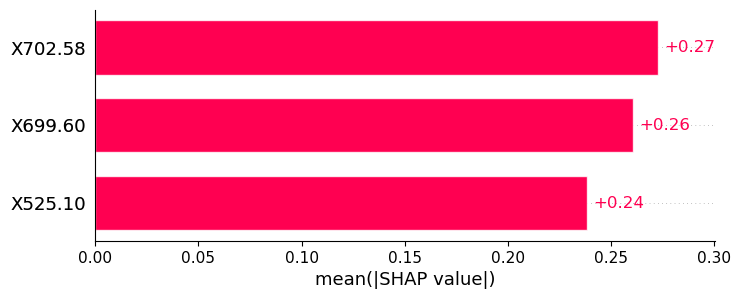

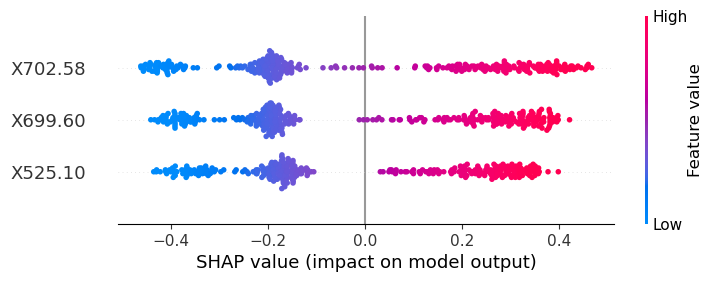

(330, 3)


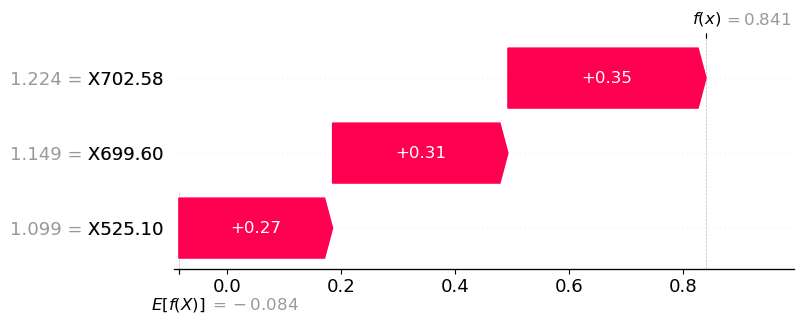

Model classes: [0 1]


In [45]:
### Hyperparameter Tuning and Cross-Validation for Standard Logistic Regression ###
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 30],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear', 'sag']
}
random_state= 42
grid_search_lr = GridSearchCV(LogisticRegression(max_iter=1000, tol=1e-3,random_state=random_state), param_grid_lr, cv=5, scoring='accuracy')
grid_search_lr.fit(X_train, y_train)
best_params_lr = grid_search_lr.best_params_
print("Best parameters for Logistic Regression:", best_params_lr)

# Print Cross-Validation Scores from GridSearchCV
cv_results = pd.DataFrame(grid_search_lr.cv_results_)
print("\nCross-Validation Scores from GridSearchCV:\n", cv_results[['mean_test_score', 'std_test_score', 'params']])

# Initialize the best logistic regression model
model = LogisticRegression(**best_params_lr, max_iter=5000, tol=1e-3, random_state=random_state)

# # Perform cross-validation
# cv_scores_lr = cross_val_score(model, X_train, y_train, cv=5)
# print("\nStandard Logistic Regression - Cross-Validation Scores:", cv_scores_lr)
# print("Mean Cross-Validation Score:", cv_scores_lr.mean())

# Train the model on the entire training set
model.fit(X_train, y_train)

# Extract coefficients and intercept
coefficients = model.coef_[0]  # For binary classification; adjust for multiclass
intercept = model.intercept_[0]  # For binary classification; adjust for multiclass
# Print coefficients and intercept with feature names
print("Intercept:", intercept)
print("Coefficients:")
for feature, coef in zip(feature_names, coefficients):
    print(f"{feature}: {coef}")
# Save the coefficients and intercept to a .txt file without rounding
output_file = "feature_coefficients_exact.txt"
with open(output_file, "w") as f:
    f.write(f"Intercept: {intercept}\n")
    f.write("Coefficients:\n")
    for feature, coef in zip(feature_names, coefficients):
        f.write(f"{feature}: {coef}\n")
print(f"Exact coefficients and intercept saved to {output_file}")

# Make predictions on the test set
y_pred = model.predict(X_scaled_te)

# Model Evaluation for Standard Logistic Regression
print("\nStandard Logistic Regression - Test Set Accuracy:", accuracy_score(y_te, y_pred))
print("Test Set Classification Report:")
print(classification_report(y_te, y_pred))

# make sure the labels match
print("Unique values in y_te:", np.unique(y_te))
print("Unique values in y_pred:", np.unique(y_pred))


# Confusion Matrix
conf_matrix = confusion_matrix(y_te, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["+N+Fe", "+N-Fe"], yticklabels=["+N+Fe", "+N-Fe"])
plt.title("Confusion Matrix - Standard Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# NEW: SHAP ANALYSIS
# Use LinearExplainer for logistic regression
explainer_llr = shap.LinearExplainer(model, X_train)
# Calculate SHAP values
shap_values_llr = explainer_llr.shap_values(X_scaled_te)
print("Linear Logistic Regression shap_values shape is", np.shape(shap_values_llr))
# Ensure base_values is an array
base_values_llr = np.full(shap_values_llr.shape[0], explainer_llr.expected_value)
# Create an Explanation object
shap_values_llr_explanation = shap.Explanation(
    shap_values_llr,
    base_values=base_values_llr,
    data=X_scaled_te,
    # feature_names = feature_names_reduced
    feature_names=feature_names
)
# Generate SHAP plots
# Summary Plot
shap.summary_plot(shap_values_llr, X_scaled_te, feature_names=feature_names)
# shap.summary_plot(shap_values_llr, X_scaled_te, feature_names=feature_names_reduced)
# Bar Plot
shap.plots.bar(shap_values_llr_explanation, max_display=10)
# Beeswarm Plot
shap.plots.beeswarm(shap_values_llr_explanation)
print(shap_values_llr_explanation.shape)
# Waterfall Plot for the first instance
shap.plots.waterfall(shap_values_llr_explanation[1])

print("Model classes:", model.classes_)

#### <font color=green> Random Forest </font>

C:\Users\hassa\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best parameters for Random Forest: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Cross-Validation Scores from GridSearchCV:
      mean_test_score  std_test_score  \
0           0.733333        0.088889   
1           0.738889        0.111941   
2           0.750000        0.120442   
3           0.744444        0.118374   
4           0.705556        0.103339   
..               ...             ...   
283         0.705556        0.137885   
284         0.688889        0.113039   
285         0.694444        0.132637   
286         0.683333        0.132171   
287         0.688889        0.131937   

                                                params  
0    {'max_depth': None, 'max_features': 'sqrt', 'm...  
1    {'max_depth': None, 'max_features': 'sqrt', 'm...  
2    {'max_depth': None, 'max_features': 'sqrt', 'm...  
3    {'max_depth': None, 'max_features': 'sqrt', 'm...  
4    {'max_depth': None, 'max_features': '

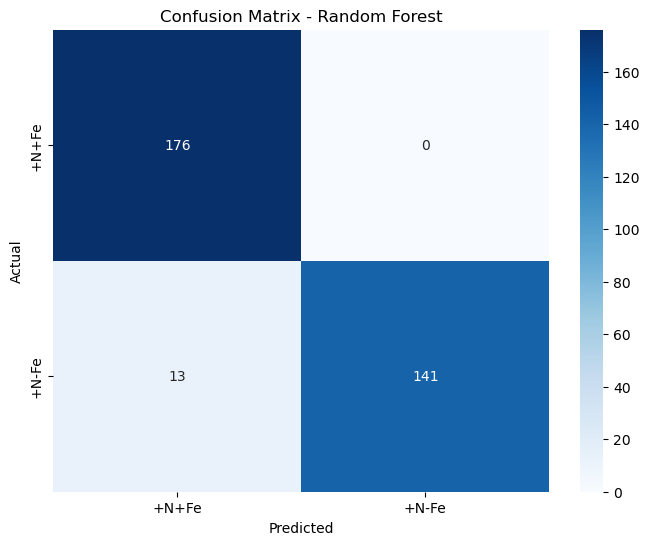

Random Forest shap_values shape is (330, 3, 2)
Selected SHAP values shape: (330, 3)


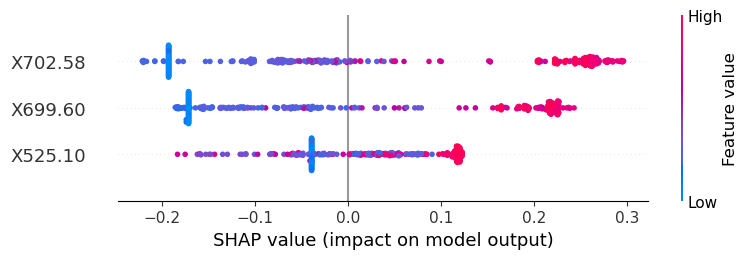

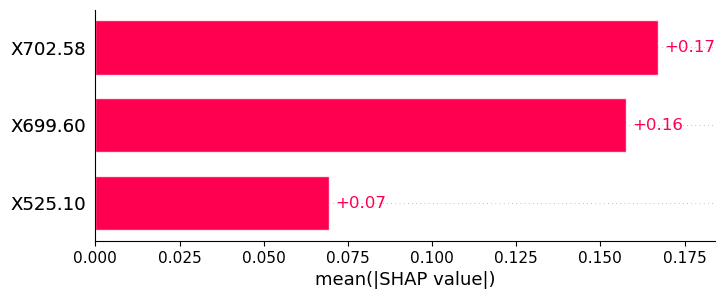

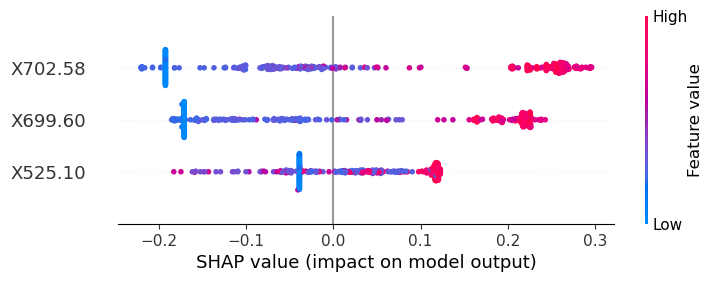

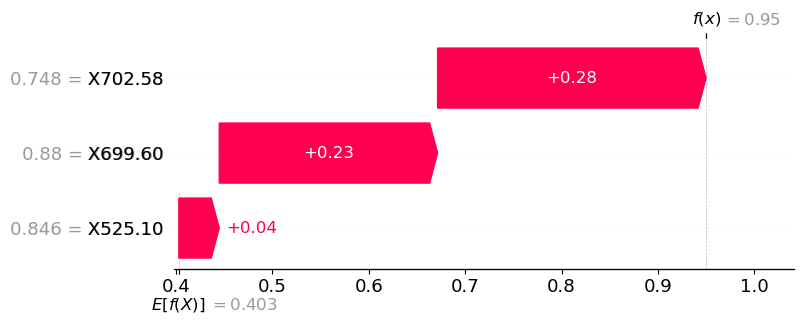

Model classes: [0 1]


In [46]:
### Random Forest Classifier ###
# Hyperparameter Tuning and Cross-Validation for Random Forest
param_grid_rf = {
    'n_estimators': [10, 50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
# Set a random_state for reproducibility
random_state = 42
grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=random_state), param_grid_rf, cv=5, scoring='accuracy')
grid_search_rf.fit(X_train, y_train)
best_params_rf = grid_search_rf.best_params_
print("Best parameters for Random Forest:", best_params_rf)

# Print Cross-Validation Scores from GridSearchCV
cv_results_rf = pd.DataFrame(grid_search_rf.cv_results_)
print("\nCross-Validation Scores from GridSearchCV:\n", cv_results_rf[['mean_test_score', 'std_test_score', 'params']])

# Initialize the best Random Forest model
rf_model = RandomForestClassifier(**best_params_rf,random_state=random_state)

# Train the model on the entire training set
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_scaled_te)

# Model Evaluation for Random Forest
print("\nRandom Forest - Test Set Accuracy:", accuracy_score(y_te, y_pred_rf))
print("Test Set Classification Report:")
print(classification_report(y_te, y_pred_rf))

# make sure the labels match
print("Unique values in y_te:", np.unique(y_te))
print("Unique values in y_pred:", np.unique(y_pred))


# Confusion Matrix
conf_matrix_rf = confusion_matrix(y_te, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt="d", cmap="Blues", xticklabels=["+N+Fe", "+N-Fe"], yticklabels=["+N+Fe", "+N-Fe"])
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# SHAP Analysis
# Use TreeExplainer for Random Forest
explainer_rf = shap.TreeExplainer(rf_model)

# Calculate SHAP values
shap_values_rf = explainer_rf.shap_values(X_scaled_te)
print("Random Forest shap_values shape is", np.shape(shap_values_rf))

# Select the SHAP values for the positive class (class 1)
shap_values_rf_selected = shap_values_rf[:, :, 1]
# Print the shape of the resulting array
print("Selected SHAP values shape:", shap_values_rf_selected.shape)

# Create an Explanation object
shap_values_rf_explanation = shap.Explanation(
    shap_values_rf_selected,
    base_values=explainer_rf.expected_value[1],  # Use the expected value of the positive class
    data=X_scaled_te,
    feature_names=feature_names
    # feature_names=feature_names_reduced
)

# Generate SHAP plots
# Summary Plot
shap.summary_plot(shap_values_rf_explanation, X_scaled_te, feature_names=feature_names)
# shap.summary_plot(shap_values_rf_explanation, X_scaled_te, feature_names=feature_names_reduced)
# Bar Plot
shap.plots.bar(shap_values_rf_explanation)

# Beeswarm Plot
shap.plots.beeswarm(shap_values_rf_explanation)

# Waterfall Plot for the first instance
shap.plots.waterfall(shap_values_rf_explanation[0])

print("Model classes:", rf_model.classes_)